# EDA — NASA CMAPSS FD001

## Contexte

Les données CMAPSS (Commercial Modular Aero-Propulsion System Simulation) sont générées  
par un simulateur de moteur turbofan développé par la NASA.

Chaque moteur démarre avec un niveau d'usure initial aléatoire et développe une dégradation  
progressive jusqu'à la panne. L'objectif est de prédire le **RUL (Remaining Useful Life)**  
— le nombre de cycles restants avant la défaillance.

**Dataset FD001** :
- 100 moteurs en entraînement, 100 en test
- 1 condition opérationnelle (Sea Level)
- 1 mode de panne (HPC Degradation)
- 21 capteurs + 3 paramètres opérationnels

**Structure des données** :
- **Train** : séquences complètes jusqu'à la panne — le RUL est calculé comme `max_cycle - cycle`
- **Test** : séquences tronquées avant la panne — le RUL réel est fourni dans `RUL_FD001.txt`

> NASA CMAPSS [readme.txt](../docs/readme.txt) · Saxena et al. (2008), p.3 — Table 2 — [PDF](../docs/Damage_Propagation_Modeling.pdf)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="darkgrid")

train = pd.read_csv("../data/processed/train_processed.csv")
test = pd.read_csv("../data/processed/test_processed.csv")

print(f"Train : {train.shape[0]} lignes, {train['unit_id'].nunique()} moteurs")
print(f"Test  : {test.shape[0]} lignes, {test['unit_id'].nunique()} moteurs")
train.head()

Train : 20631 lignes, 100 moteurs
Test  : 13096 lignes, 100 moteurs


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [30]:
print("Doublons :", train.duplicated().sum())
print("Valeurs manquantes :", train.isna().sum().sum())
print("Colonnes :", train.shape[1])
print("\nTypes :")
print(train.dtypes.value_counts())

Doublons : 0
Valeurs manquantes : 0
Colonnes : 27

Types :
float64    22
int64       5
Name: count, dtype: int64


In [31]:
print("=== Infos générales ===")
print(f"Moteurs train : {train['unit_id'].nunique()}")
print(f"Cycles min/max : {train['cycle'].min()} / {train['cycle'].max()}")
print(f"RUL min/max : {train['RUL'].min()} / {train['RUL'].max()}")
print(f"Nulls : {train.isnull().sum().sum()}")

print("\n=== Durée de vie par moteur ===")
life = train.groupby("unit_id")["cycle"].max()
print(f"Durée moyenne : {life.mean():.1f} cycles")
print(f"Durée min : {life.min()} cycles")
print(f"Durée max : {life.max()} cycles")

=== Infos générales ===
Moteurs train : 100
Cycles min/max : 1 / 362
RUL min/max : 0 / 361
Nulls : 0

=== Durée de vie par moteur ===
Durée moyenne : 206.3 cycles
Durée min : 128 cycles
Durée max : 362 cycles


In [32]:
op_cols = [col for col in train.columns if col.startswith("op_setting_")]
train[op_cols].describe()

,op_setting_1,op_setting_2,op_setting_3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


## Distribution du RUL

La distribution du RUL n'est pas uniforme au niveau global.  
Les faibles valeurs de RUL sont présentes pour tous les moteurs, tandis que 
les valeurs élevées n'apparaissent que pour les moteurs ayant une longue durée de vie.

> NASA CMAPSS [readme.txt](../docs/readme.txt) · Saxena et al. (2008), p.5 — Section V.A — [PDF](../docs/Damage_Propagation_Modeling.pdf)

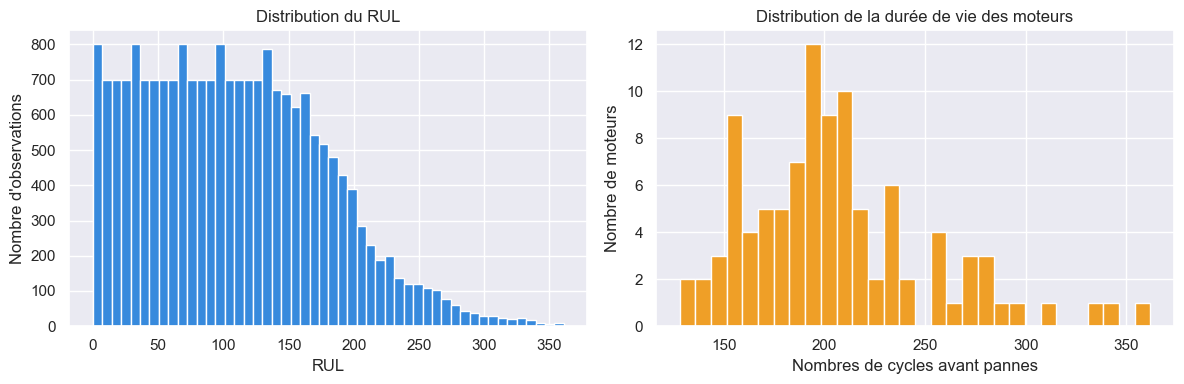

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(train["RUL"], bins=50, color = "#378ADD", edgecolor= "white")
axes[0].set_title("Distribution du RUL")
axes[0].set_xlabel("RUL")
axes[0].set_ylabel("Nombre d'observations")

life= train.groupby("unit_id")["cycle"].max()
axes[1].hist(life, bins=30,color = "#EF9F27", edgecolor = "white")
axes[1].set_title("Distribution de la durée de vie des moteurs")
axes[1].set_xlabel("Nombres de cycles avant pannes")
axes[1].set_ylabel("Nombre de moteurs")

plt.tight_layout()
plt.show()

## Observations

- La distribution du RUL est **décroissante** : beaucoup d'observations proches de 0  
  car tous les moteurs atteignent la panne, peu d'observations à RUL élevé  
  car seuls les moteurs à longue durée de vie les atteignent.
- La durée de vie moyenne est **~206 cycles**, avec une forte variabilité (128 à 362).  
  Cette variabilité est intentionnelle dans C-MAPSS — chaque moteur démarre  
  avec une usure initiale aléatoire (Saxena et al., 2008).

## Analyse des capteurs

Les 21 capteurs ne sont pas tous utiles pour prédire le RUL.  
Certains sont **constants** sur toute la durée de vie — ils n'apportent aucune information.  
D'autres montrent une **tendance de dégradation** claire — ce sont ceux qu'on garde.

On commence par identifier les capteurs constants en calculant leur écart-type.  
Un écart-type proche de 0 = capteur inutile.

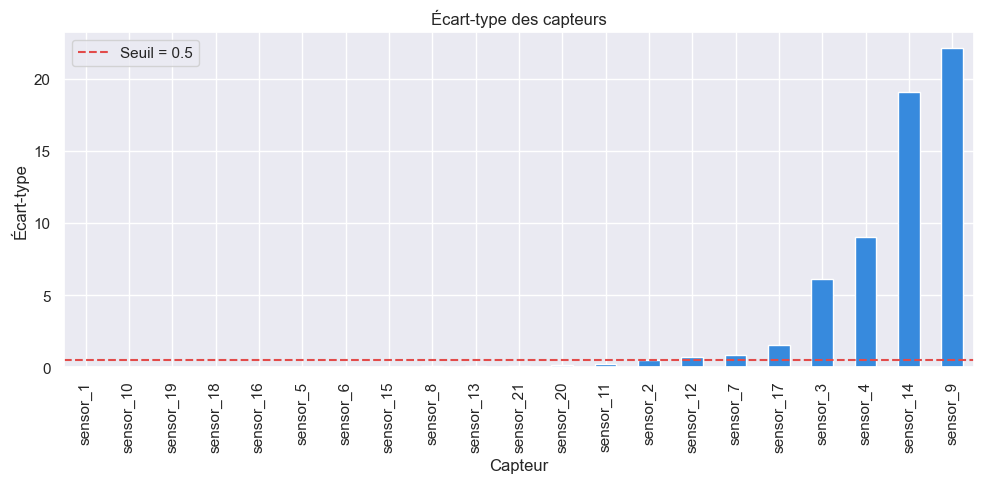

Capteurs candidats à l'élimination (std < 0.5) :
['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5', 'sensor_6', 'sensor_15', 'sensor_8', 'sensor_13', 'sensor_21', 'sensor_20', 'sensor_11']


In [34]:
sensor_cols = [col for col in train.columns if col.startswith("sensor_")]
sensor_std = train[sensor_cols].std().sort_values()

threshold = 0.5

fig, ax = plt.subplots(figsize=(10, 5))
sensor_std.plot(kind="bar", ax=ax, color="#378ADD", edgecolor="white")
ax.axhline(y=threshold, color="#E24B4A", linestyle="--", label=f"Seuil = {threshold}")
ax.set_title("Écart-type des capteurs")
ax.set_xlabel("Capteur")
ax.set_ylabel("Écart-type")
ax.legend()
plt.tight_layout()
plt.show()

print("Capteurs candidats à l'élimination (std < 0.5) :")
print(sensor_std[sensor_std < threshold].index.tolist())

## Capteurs retenus

**Capteurs candidats à l'élimination** (std < 0.5) — quasi-constants, variation 
attribuable au bruit de mesure.

**Capteurs prioritaires** pour le feature engineering :  
`sensor_2, sensor_3, sensor_4, sensor_7, sensor_9, sensor_12, sensor_14, sensor_17`

> NASA CMAPSS [readme.txt](../docs/readme.txt) · Saxena et al. (2008), p.5-6 — Section V.B — [PDF](../docs/Damage_Propagation_Modeling.pdf)

## Dégradation des capteurs

On visualise l'évolution des 8 capteurs retenus sur la durée de vie d'un moteur.  
Un capteur utile doit montrer une tendance claire de dégradation au fil des cycles.

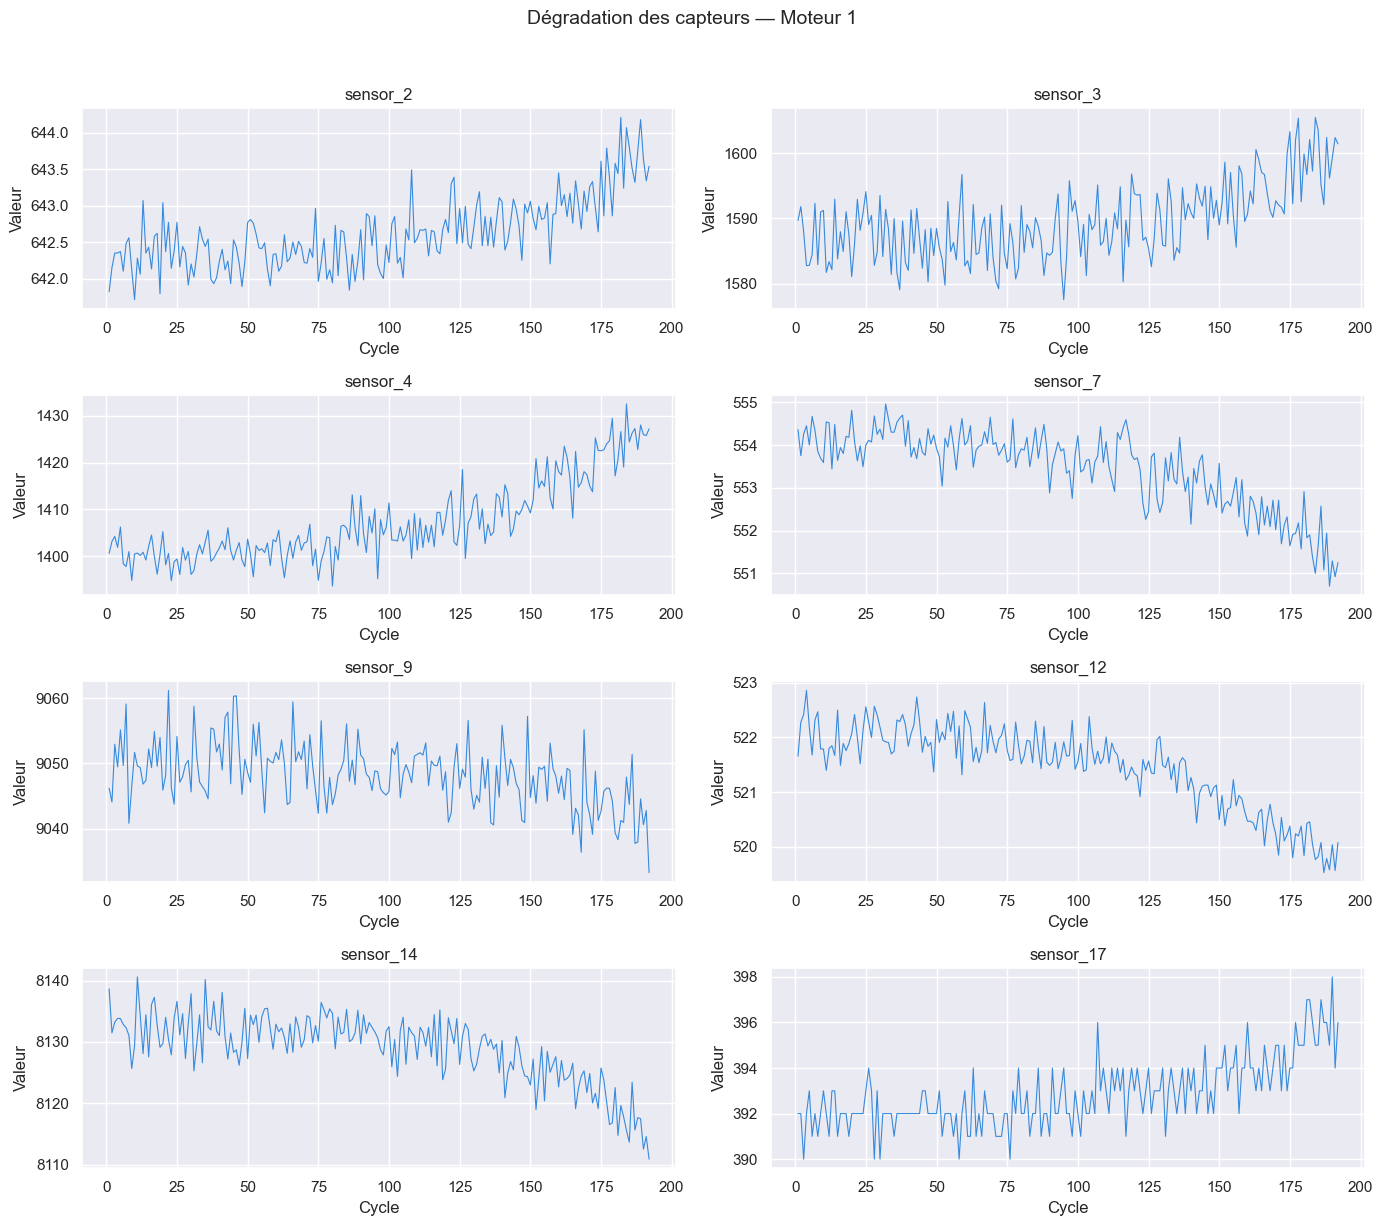

In [35]:
USEFUL_SENSORS = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", 
                   "sensor_9", "sensor_12", "sensor_14", "sensor_17"]

motor = train[train["unit_id"] == 1]

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, sensor in enumerate(USEFUL_SENSORS):
    axes[i].plot(motor["cycle"], motor[sensor], color="#378ADD", linewidth=0.8)
    axes[i].set_title(sensor)
    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel("Valeur")

plt.suptitle("Dégradation des capteurs — Moteur 1", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

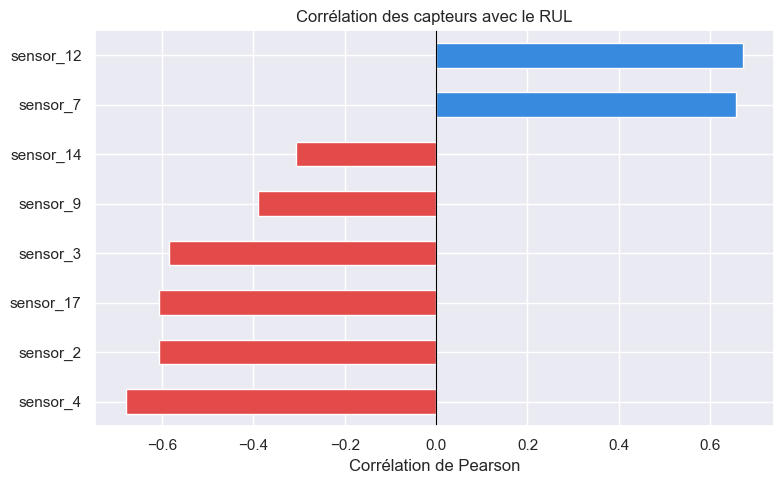

In [36]:
corr = train[USEFUL_SENSORS + ["RUL"]].corr()["RUL"].drop("RUL").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind="barh", ax=ax, color=["#E24B4A" if v < 0 else "#378ADD" for v in corr])
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Corrélation des capteurs avec le RUL")
ax.set_xlabel("Corrélation de Pearson")
plt.tight_layout()
plt.show()

## Corrélation capteurs / RUL

Une corrélation **négative** avec le RUL signifie que le capteur tend à **augmenter** 
lorsque le moteur se rapproche de la panne.

Une corrélation **positive** avec le RUL signifie que le capteur tend à **diminuer** 
lorsque le moteur se dégrade.

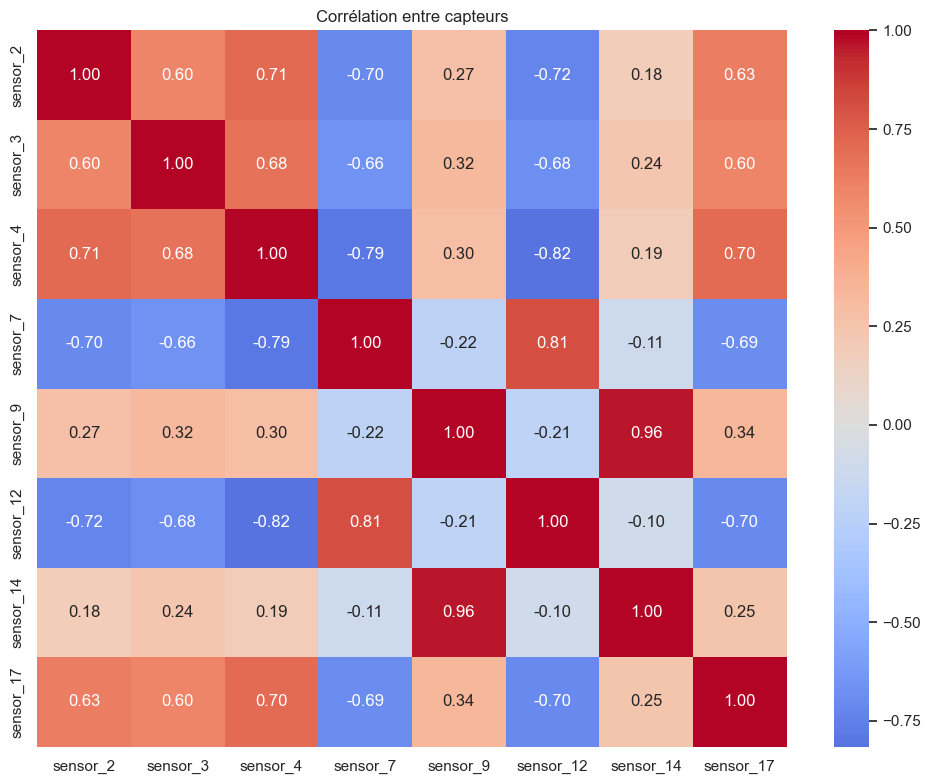

In [37]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    train[USEFUL_SENSORS].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax
)
ax.set_title("Corrélation entre capteurs")
plt.tight_layout()
plt.show()

## Conclusions & décisions pour le preprocessing

- Le dataset FD001 contient **100 moteurs train** et **100 moteurs test**.
- **Aucune valeur manquante** détectée.
- Les durées de vie varient fortement entre moteurs : **128 à 362 cycles**.
- La distribution du RUL est **décroissante** — seuls les moteurs à longue durée de vie atteignent les grands RUL.
- Certains capteurs sont quasi-constants et seront **candidats à suppression** lors du preprocessing.
- Les capteurs présentant une tendance visible seront **prioritaires** pour le feature engineering.
- D'après le [PDF](../docs/Damage_Propagation_Modeling.pdf) (p.7 - Section VI), les RUL du test set sont compris **entre 10 et 150 cycles**, un RUL cappé à **150 cycles** sera donc utilisé comme hypothèse de modélisation afin d’aligner la cible d’apprentissage avec cette échelle documentée, tout en limitant l’influence des très grands RUL.

> Saxena et al. (2008), p.7 — Section VI — [PDF](../docs/Damage_Propagation_Modeling.pdf)